### **Import Libraries & Check Keras Version**

In [3]:
import tensorflow as tf

print("Keras Version:", tf.keras.__version__)

Keras Version: 3.13.2


### **Why Not NumPy**

In [4]:
import numpy as np

# f(x) = x^2
def f(x):
    return x**2

# gradient = 2x
def gradient(x):
    return 2*x

x = 5.0
learning_rate = 0.1

for i in range(10):
    x = x - learning_rate * gradient(x)

print("Final x:", x)
print("f(x):", f(x))

Final x: 0.5368709120000001
f(x): 0.2882303761517119


### **Gradient using Keras (Automatic)**

In [5]:
x = tf.Variable(5.0)

with tf.GradientTape() as tape:
    y = x**2

grad = tape.gradient(y, x)

print("Gradient:", grad.numpy())

Gradient: 10.0


### **Dense Layer Example**

In [6]:
from tensorflow.keras.layers import Dense

layer = Dense(64, activation="sigmoid")
print(layer)

<Dense name=dense, built=False>


### **Load MNIST Dataset**

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## **Preprocessing**

In [29]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten (28x28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(60000, 784) (60000, 10)


### **Build Model (Sequential)**

In [30]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

## **Model Summary**

In [31]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

### **Compile Model**

In [32]:
model.compile(
    optimizer="sgd",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### **Train Model**

In [33]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.15
)

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1115 - loss: 2.3058 - val_accuracy: 0.1028 - val_loss: 2.3020
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1171 - loss: 2.3002 - val_accuracy: 0.1063 - val_loss: 2.3002
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1186 - loss: 2.2985 - val_accuracy: 0.1063 - val_loss: 2.2982
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1221 - loss: 2.2969 - val_accuracy: 0.1063 - val_loss: 2.2982
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1279 - loss: 2.2952 - val_accuracy: 0.1063 - val_loss: 2.2959
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1296 - loss: 2.2933 - val_accuracy: 0.1768 - val_loss: 2.2917
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1350 - loss: 2.2907 - val_accuracy: 0.1079 - val_loss: 2.2901
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1396 - loss: 2.2883 - val_accuracy: 0.

### **Evaluate**

In [36]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1136 - loss: 2.2783
Test Accuracy: 0.1136000007390976


### **Prediction**

In [37]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted: 1
Actual: 7


### **Save Model**

In [38]:
model.save("mnist_fcn_model.h5")

### **Load Model**

In [39]:
loaded_model = tf.keras.models.load_model("mnist_fcn_model.h5")

loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1136 - loss: 2.2783


[2.2782936096191406, 0.1136000007390976]

### **Devnagari Dataset**

In [49]:
import os
train_dir = "/content/drive/MyDrive/AI/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

In [50]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

In [51]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))  # digit_0, digit_1...
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image
            img = Image.open(img_path).convert("L")   # grayscale
            img = img.resize((img_width, img_height))  # resize
            img = np.array(img) / 255.0  # normalize

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


In [52]:
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Train shape: (4652, 28, 28)
Test shape: (2100, 28, 28)


In [55]:
# Add channel dimension (VERY IMPORTANT)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("New shape:", x_train.shape)

New shape: (4652, 28, 28, 1)


In [56]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Label shape:", y_train.shape)

Label shape: (4652, 10)


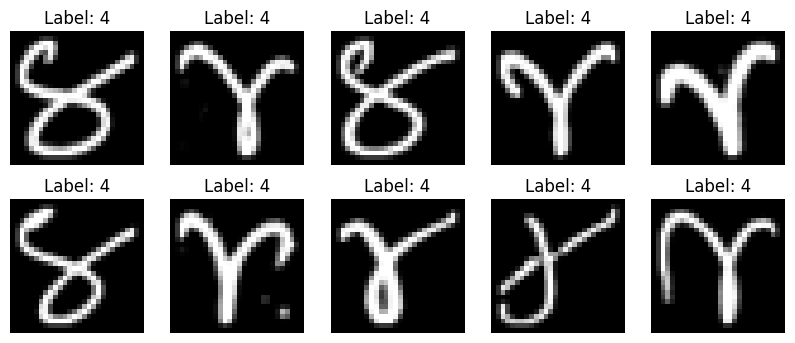

In [57]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Label: " + str(np.argmax(y_train[i])))
    plt.axis('off')

plt.show()

In [58]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28, 1)),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [59]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4561 - loss: 1.1053 - val_accuracy: 0.0000e+00 - val_loss: 2.2548
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8100 - loss: 0.6866 - val_accuracy: 0.0000e+00 - val_loss: 2.1219
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9162 - loss: 0.2673 - val_accuracy: 0.4984 - val_loss: 0.9764
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9785 - loss: 0.1149 - val_accuracy: 0.7347 - val_loss: 0.6600
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9874 - loss: 0.0607 - val_accuracy: 0.8077 - val_loss: 0.4874
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9911 - loss: 0.0434 - val_accuracy: 0.7787 - val_loss: 0.5594
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0331 - val_accuracy: 0.8002 - val_loss: 0.5117
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9944 - loss: 0.0276 - val_accuracy: 0.8475 - 

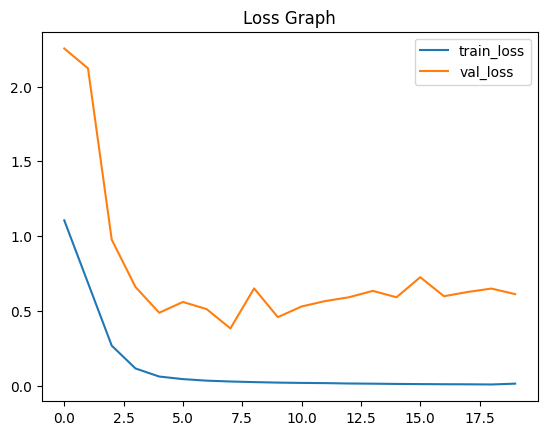

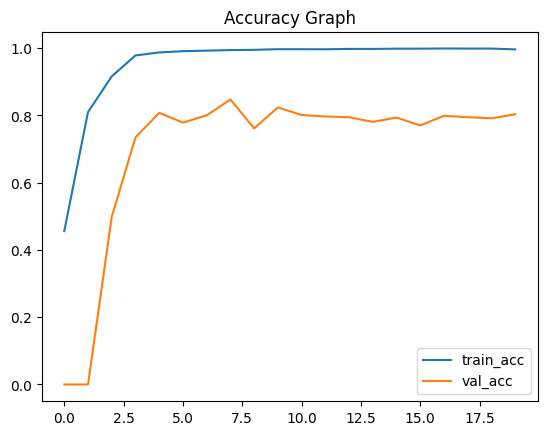

In [62]:
# Loss graph
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

In [63]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4090 - loss: 6.8133
Test Accuracy: 0.4090476334095001


In [64]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 5
Actual: 2


In [65]:
model.save("devnagari_model.h5")

In [66]:
loaded_model = tf.keras.models.load_model("devnagari_model.h5")

loaded_model.evaluate(x_test, y_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4090 - loss: 6.8133


[6.813303470611572, 0.4090476334095001]